<a href="https://colab.research.google.com/github/SaydobidXusanov/Multimedia-Computing/blob/main/MC_Opening_%26_Closing_Using_A_Structuring_Element.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Opening & Closing Using A Structuring Element (MC)
**Author:** Saydobid Khusanov  
**ID: U2110180**  
October 12, 2024

The used image is a copyright.

## Data Preparation

In [1]:
# Imports
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

In [43]:
# Read the image
image = cv2.imread('sample.jpg')

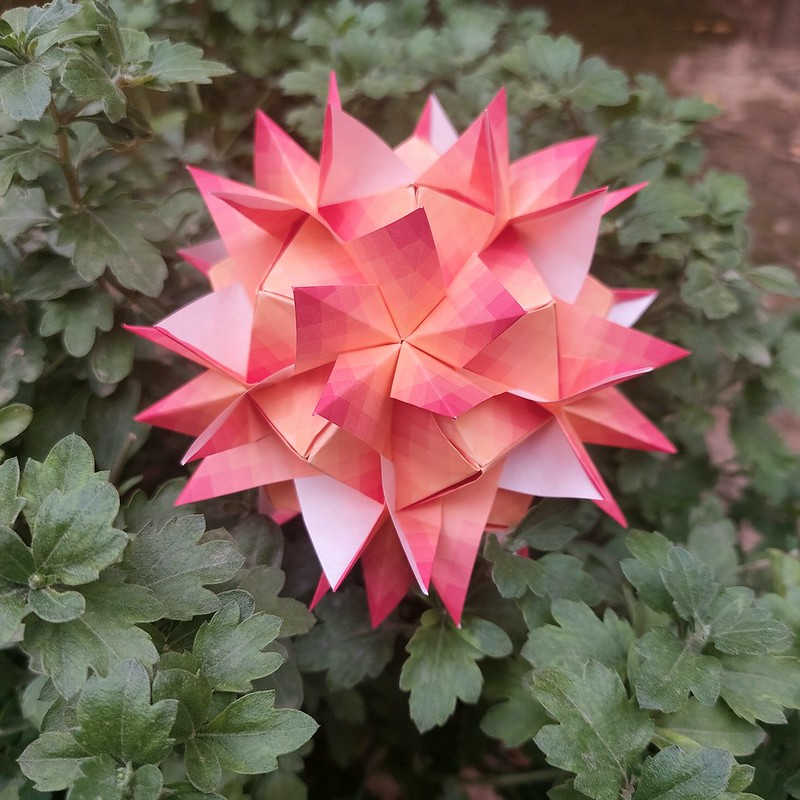

In [44]:
cv2_imshow(image)

In [45]:
# Convert image to grayscale
gray_img = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

array([[ 52,  51,  49, ...,  77,  78,  77],
       [ 54,  52,  50, ...,  78,  79,  78],
       [ 52,  50,  48, ...,  79,  79,  78],
       ...,
       [102,  98,  96, ...,  84,  81,  76],
       [102, 100,  97, ...,  63,  72,  72],
       [ 98, 101,  99, ...,  31,  48,  55]], dtype=uint8)
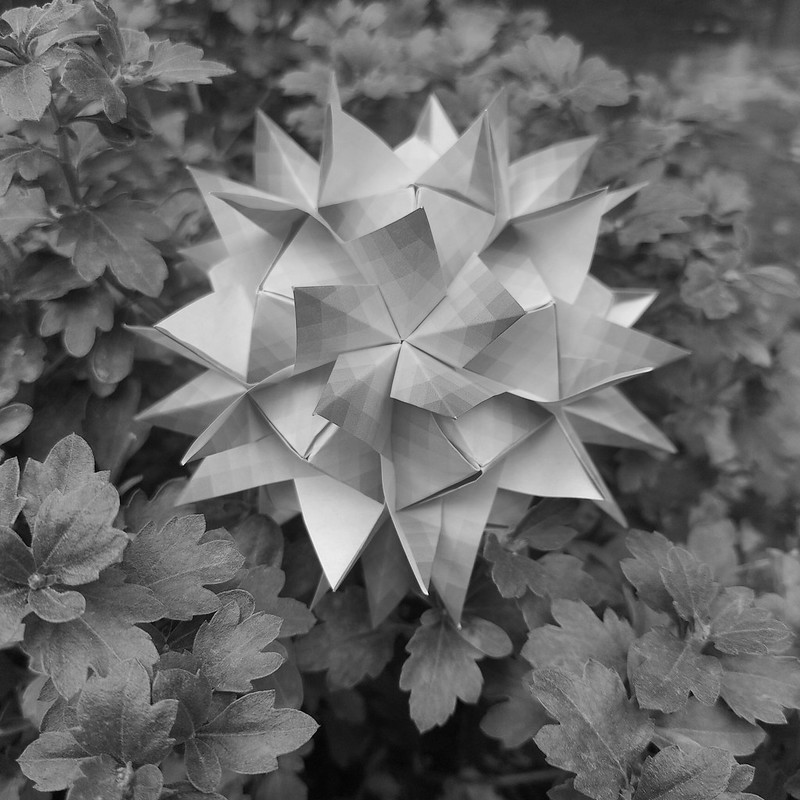

In [46]:
gray_img

In [47]:
# Convert grayscale image to binary
_, binary_img = cv2.threshold(gray_img, 127, 255, cv2.THRESH_BINARY)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)
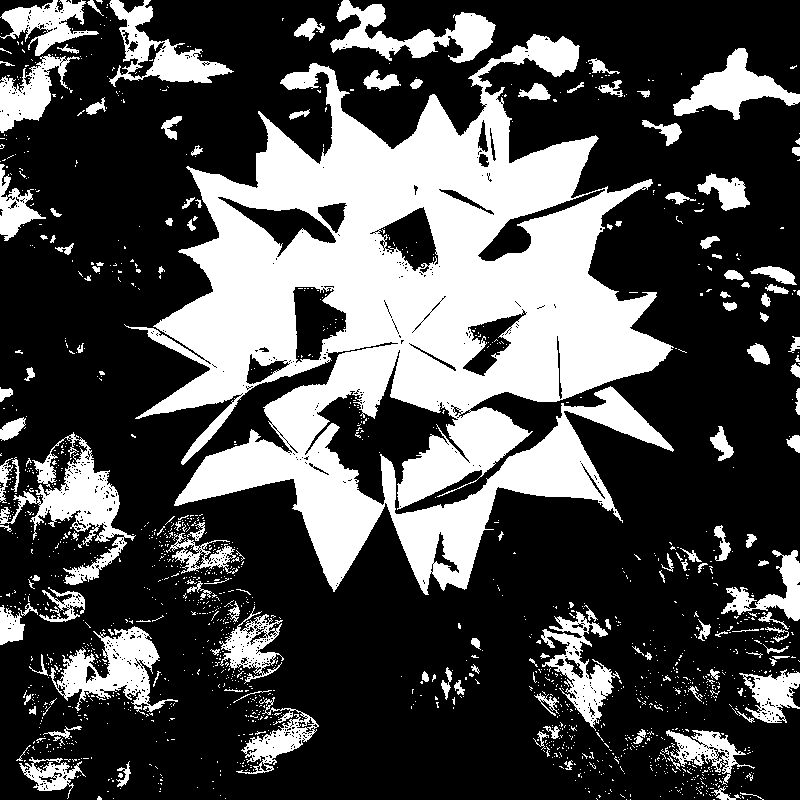

In [48]:
binary_img

## Terms

A Θ B - **Erosion**

A ⊕ B - **Dilation**

## Structuring Element

**Kernel or S:** 3x3 Matrix of 1's

In [49]:
# Define the structuring element
S = np.ones((3, 3))

In [50]:
S, S.shape

(array([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]]),
 (3, 3))

## Apply Opening
**Opening:**  
A ○ B = (A Θ B) ⊕ B

In [51]:
# First: Apply Erosion C = (A Θ B)
A_erode_S = cv2.erode(binary_img, S)

In [52]:
# Second: Apply Dilation (C ⊕ B)
C_dilate_B = cv2.dilate(A_erode_S, S)

In [53]:
opening = C_dilate_B

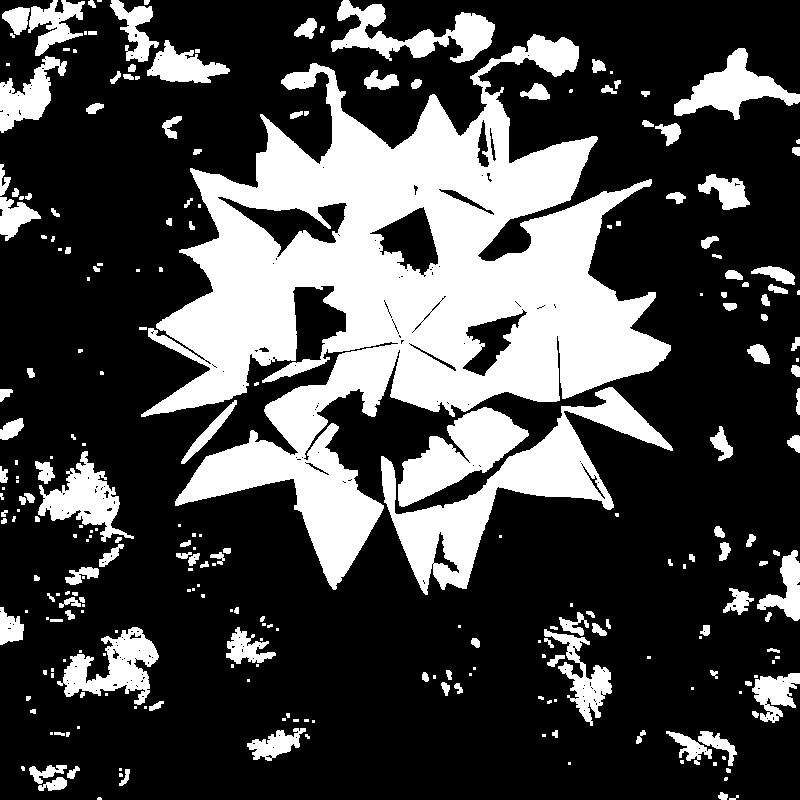

In [54]:
cv2_imshow(opening)

## Apply Closing
**Closing:**  
A ● B = (A ⊕ B) Θ B

In [55]:
# First: Apply Dilation C = (A ⊕ B)
A_dilate_S = cv2.dilate(binary_img, S)

In [56]:
# Second: Apply Erosion C Θ B
C_erode_S = cv2.erode(A_dilate_S, S)

In [57]:
closing = C_erode_S

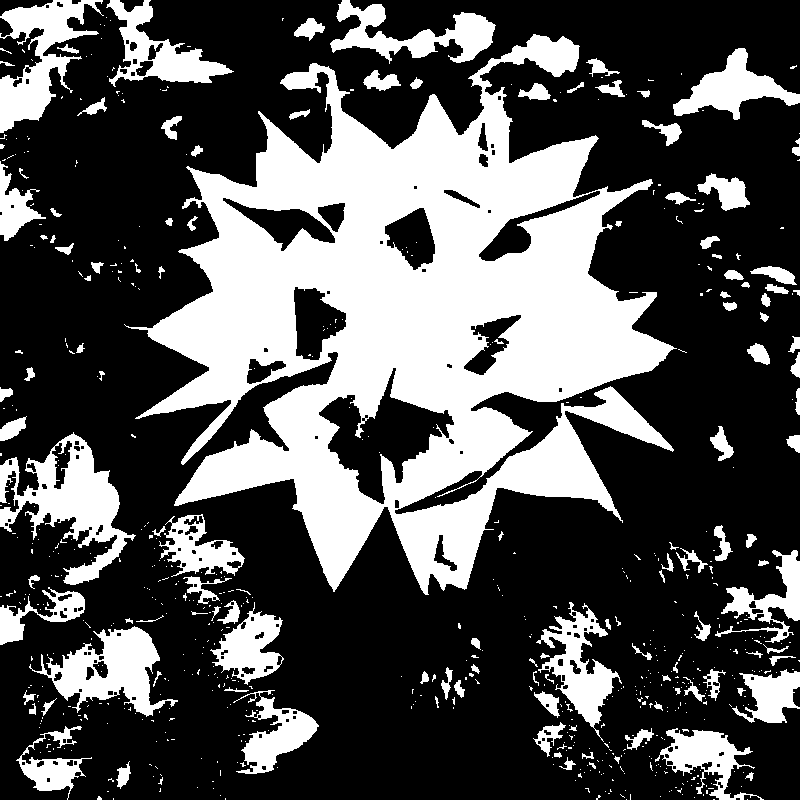

In [58]:
cv2_imshow(closing)

## Display Final Results

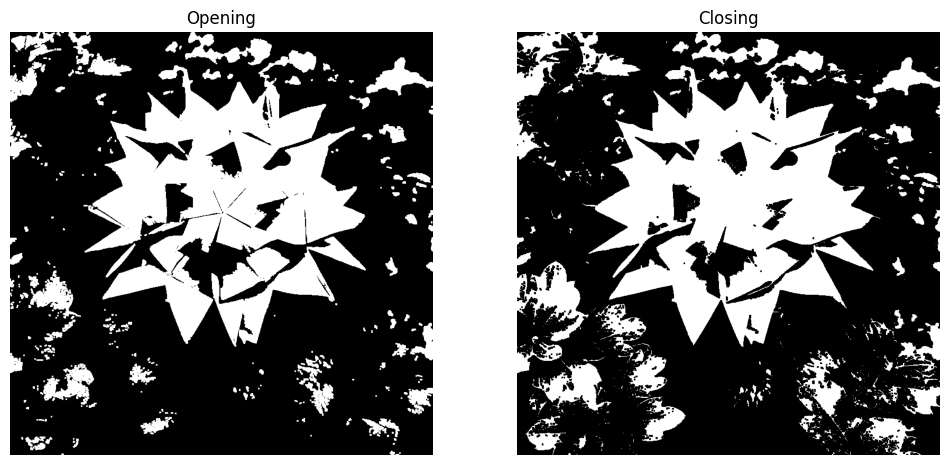

In [59]:
# Display Opening and Closing Results
plt.figure(figsize=(12, 8))

plt.subplot(1, 2, 1)
plt.imshow(opening, cmap="gray")
plt.title('Opening')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(closing, cmap="gray")
plt.title('Closing')
plt.axis('off')

plt.show()